# 🚀 Bit-MC-SSM Phase 1: Prototype & Training in PyTorch
### **CPU-Native 1.58-bit Memory-Cached State Space Model**
**〜 GPU・小数の行列演算依存からの完全脱却を目指す次世代CPU特化型LLM 〜**

---

## 🎯 このノートブックの目的
1. **BitNet 1.58-bit (Ternary STE) の動作実証:** 重み $\{-1, 0, +1\}$ と INT8 活性化による乗算ゼロ線形変換。
2. **Shift-SSM (Bit-Shift State Space Model):** 指数関数・連続計算を排除した、ビットシフト親和的な状態更新。
3. **Memory Caching (MC-SSC, arXiv:2602.24281):** セグメント分割 ＋ Top-$k$ 疎ルーティングによる超軽量長期記憶。
4. **言語モデル学習 & テキスト生成:** TinyStories 等のデータセットで学習し、文法獲得と生成能力を検証。

## 📦 1. 環境セットアップ & ライブラリ導入
Google Colab (GPU) または ローカル環境 (CPU/GPU) のどちらでもそのまま動作します。

In [1]:
# 必要なライブラリのインストール (Colab等の場合)
!pip install -q torch datasets transformers matplotlib tiktoken

In [2]:
import math
import time
from typing import Optional, List, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# デバイスの自動検出
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"⚡ Using Device: {device}")
if device.type == "cuda":
    print(f"   GPU Name: {torch.cuda.get_device_name(0)}")
elif device.type == "cpu":
    print(f"   CPU Threads: {torch.get_num_threads()}")

⚡ Using Device: cuda
   GPU Name: Tesla T4


## ⚙️ 2. BitLinear 1.58-bit (STE & INT8 Activation)
重みを $\{-1, 0, +1\}$ の3値にスケール量子化し、活性化を8-bit整数（INT8）に量子化します。
逆伝播時は **Straight-Through Estimator (STE)** により、背後にある潜伏重み（FP32/BF16）へ勾配を流します。

In [3]:
def weight_quant(w: torch.Tensor, eps: float = 1e-5) -> torch.Tensor:
    """
    Ternary weight quantization to {-1, 0, +1} using BitNet b1.58 formula.
    W_quant = clip(round(W / gamma), -1, 1) * gamma
    """
    gamma = torch.mean(torch.abs(w)) + eps
    w_scaled = w / gamma
    w_quant = torch.clamp(torch.round(w_scaled), -1.0, 1.0) * gamma
    # STE: 順伝播は w_quant、逆伝播は元の w に勾配を通す
    return w + (w_quant - w).detach()

def activation_quant(x: torch.Tensor, eps: float = 1e-5) -> torch.Tensor:
    """
    8-bit activation quantization to [-128, 127].
    """
    scale = 127.0 / (torch.max(torch.abs(x), dim=-1, keepdim=True)[0] + eps)
    x_scaled = x * scale
    x_quant = torch.clamp(torch.round(x_scaled), -128.0, 127.0) / scale
    # STE
    return x + (x_quant - x).detach()

class BitLinear158(nn.Linear):
    """
    BitNet 1.58-bit Linear Layer.
    推論時は乗算を一切使わず、CPU SIMD整数加減算のみで動作。
    """
    def __init__(self, in_features: int, out_features: int, bias: bool = False):
        super().__init__(in_features, out_features, bias=bias)
        nn.init.normal_(self.weight, std=math.sqrt(2.0 / (in_features + out_features)))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_q = activation_quant(x)
        w_q = weight_quant(self.weight)
        return F.linear(x_q, w_q, self.bias)

class RMSNorm(nn.Module):
    """Root Mean Square Layer Normalization"""
    def __init__(self, dim: int, eps: float = 1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        variance = x.pow(2).mean(-1, keepdim=True)
        x_norm = x * torch.rsqrt(variance + self.eps)
        return self.weight * x_norm

## 🔄 3. Shift-SSM (Bit-Shift State Space Model)
小数の指数関数・微分方程式を排除し、**1D Causal Convolution** と **ビット右シフト減衰 ($2^{-s}$)** による整数親和的なリカレント状態更新を行います。

In [4]:
class ShiftSSM(nn.Module):
    """
    Shift-SSM: 局所セグメント内のトークン混合 & 状態更新
    """
    def __init__(self, d_model: int, d_state: int = 16, conv_kernel: int = 4):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.conv_kernel = conv_kernel

        # 1.58-bit BitLinear 射影層
        self.in_proj = BitLinear158(d_model, d_model * 2)
        self.b_proj = BitLinear158(d_model, d_state)
        self.c_proj = BitLinear158(d_model, d_state)
        self.out_proj = BitLinear158(d_model, d_model)

        # 局所コンテキスト用の1D Causal Conv
        self.conv1d = nn.Conv1d(
            in_channels=d_model,
            out_channels=d_model,
            kernel_size=conv_kernel,
            padding=conv_kernel - 1,
            groups=d_model
        )

        # 学習可能な対数減衰係数 (推論時はシフト量 s に丸め)
        self.decay_param = nn.Parameter(torch.randn(d_state) * 0.1 - 1.0)

    def forward(self, x: torch.Tensor, initial_state: Optional[torch.Tensor] = None) -> Tuple[torch.Tensor, torch.Tensor]:
        b, l, d = x.shape

        # 1. 入力射影 & ゲート分離
        projected = self.in_proj(x)
        u, gate = torch.chunk(projected, 2, dim=-1)

        # 2. 1D Causal Conv
        u_conv = self.conv1d(u.transpose(1, 2))[:, :, :l].transpose(1, 2)
        u_conv = F.silu(u_conv)

        # 3. B, C 射影
        B = self.b_proj(u_conv)
        C = self.c_proj(u_conv)

        # 4. 減衰係数 (0 < decay < 1)
        decay = torch.sigmoid(self.decay_param).unsqueeze(0).unsqueeze(0)

        # 5. リカレント状態更新ループ
        h_t = initial_state if initial_state is not None else torch.zeros(b, self.d_state, device=x.device, dtype=x.dtype)
        state_outputs = []

        for t in range(l):
            u_t = u_conv[:, t, :].mean(dim=-1, keepdim=True)
            b_t = B[:, t, :]
            h_t = decay.squeeze(1) * h_t + b_t * u_t

            c_t = C[:, t, :]
            state_val = (c_t * h_t).sum(dim=-1, keepdim=True)
            state_outputs.append(state_val)

        state_seq = torch.cat(state_outputs, dim=-1).unsqueeze(-1)
        mixed = u_conv + state_seq.expand(-1, -1, d)
        gated = mixed * F.silu(gate)
        out = self.out_proj(gated)

        return out, h_t

## 🧠 4. Sparse Selective Memory Caching (MC-SSC, arXiv:2602.24281)
系列をセグメント長 $C$（例: 32〜128）ごとに分割し、末尾のチェックポイント状態 $\mathcal{M}^{(s)}$ を保存。
現在のトークン $q_t$ と過去セグメント平均キーの内積類似度を計算し、**Top-$k$（例: $k=2$）個のチェックポイントのみを抽出・合成**します。

In [5]:
class MemoryCachingSSC(nn.Module):
    """
    Memory Caching with Sparse Selective Caching (SSC)
    """
    def __init__(self, d_model: int, d_state: int = 16, segment_len: int = 32, top_k: int = 2):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.segment_len = segment_len
        self.top_k = top_k

        self.ssm = ShiftSSM(d_model=d_model, d_state=d_state)
        self.query_proj = BitLinear158(d_model, d_model)
        self.key_proj = BitLinear158(d_model, d_model)
        self.gate_proj = BitLinear158(d_model, 2) # [gamma_online, gamma_cached]
        self.cache_out_proj = BitLinear158(d_state, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, l, d = x.shape
        num_segments = math.ceil(l / self.segment_len)

        segment_outputs = []
        cached_states: List[torch.Tensor] = []
        cached_keys: List[torch.Tensor] = []
        current_state = None

        for s in range(num_segments):
            start_idx = s * self.segment_len
            end_idx = min((s + 1) * self.segment_len, l)
            seg_x = x[:, start_idx:end_idx, :]
            seg_len = end_idx - start_idx

            # 1. 局所セグメントを ShiftSSM で更新
            ssm_out, current_state = self.ssm(seg_x, initial_state=current_state)

            # 2. 過去チェックポイントが存在する場合、Top-k 疎ルーティング抽出
            if len(cached_states) > 0 and self.top_k > 0:
                queries = self.query_proj(seg_x)
                k_stack = torch.stack(cached_keys, dim=1)
                s_stack = torch.stack(cached_states, dim=1)

                # 類似度スコア
                scores = torch.einsum("btd, bcd -> btc", F.normalize(queries, dim=-1), F.normalize(k_stack, dim=-1))

                # Top-k 選択
                k_val = min(self.top_k, len(cached_states))
                topk_scores, topk_indices = torch.topk(scores, k=k_val, dim=-1)
                topk_weights = F.softmax(topk_scores, dim=-1)

                # 選択されたチェックポイントの集約
                topk_indices_expanded = topk_indices.unsqueeze(-1).expand(-1, -1, -1, self.d_state)
                s_stack_expanded = s_stack.unsqueeze(1).expand(-1, seg_len, -1, -1)
                gathered_states = torch.gather(s_stack_expanded, 2, topk_indices_expanded)

                retrieved_state = (gathered_states * topk_weights.unsqueeze(-1)).sum(dim=2)
                retrieved_info = self.cache_out_proj(retrieved_state)

                # Gated 残差加算
                gates = F.softmax(self.gate_proj(seg_x), dim=-1)
                g_online, g_cached = gates[..., 0:1], gates[..., 1:2]
                seg_out = g_online * ssm_out + g_cached * retrieved_info
            else:
                seg_out = ssm_out

            segment_outputs.append(seg_out)

            # 3. セグメント末尾の状態とキーをチェックポイント保管
            cached_states.append(current_state.clone())
            seg_mean_key = self.key_proj(seg_x.mean(dim=1))
            cached_keys.append(seg_mean_key)

        return torch.cat(segment_outputs, dim=1)

## 🏗️ 5. 全体統合モデル: `BitMCSSMForCausalLM`

In [6]:
class BitMCSSMBlock(nn.Module):
    def __init__(self, d_model: int, d_state: int = 16, segment_len: int = 32, top_k: int = 2, ffn_mult: int = 2):
        super().__init__()
        self.norm1 = RMSNorm(d_model)
        self.mc_ssm = MemoryCachingSSC(d_model=d_model, d_state=d_state, segment_len=segment_len, top_k=top_k)

        self.norm2 = RMSNorm(d_model)
        d_ffn = d_model * ffn_mult
        self.ffn_in = BitLinear158(d_model, d_ffn * 2)
        self.ffn_out = BitLinear158(d_ffn, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.mc_ssm(self.norm1(x))
        norm_x = self.norm2(x)
        ffn_proj = self.ffn_in(norm_x)
        w1, w2 = torch.chunk(ffn_proj, 2, dim=-1)
        ffn_act = F.silu(w1) * w2
        x = x + self.ffn_out(ffn_act)
        return x

class BitMCSSMForCausalLM(nn.Module):
    def __init__(
        self,
        vocab_size: int = 256,
        d_model: int = 128,
        n_layers: int = 4,
        d_state: int = 16,
        segment_len: int = 32,
        top_k: int = 2,
        ffn_mult: int = 2
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model

        self.embedding = nn.Embedding(vocab_size, d_model)
        nn.init.normal_(self.embedding.weight, std=0.02)

        self.blocks = nn.ModuleList([
            BitMCSSMBlock(
                d_model=d_model,
                d_state=d_state,
                segment_len=segment_len,
                top_k=top_k,
                ffn_mult=ffn_mult
            )
            for _ in range(n_layers)
        ])

        self.final_norm = RMSNorm(d_model)
        self.lm_head = BitLinear158(d_model, vocab_size, bias=False)

    def forward(self, input_ids: torch.Tensor, targets: Optional[torch.Tensor] = None) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        x = self.embedding(input_ids)
        for block in self.blocks:
            x = block(x)
        x = self.final_norm(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, self.vocab_size), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, input_ids: torch.Tensor, max_new_tokens: int = 100, temperature: float = 0.8, top_k: int = 30) -> torch.Tensor:
        self.eval()
        for _ in range(max_new_tokens):
            logits, _ = self.forward(input_ids)
            next_token_logits = logits[:, -1, :] / max(temperature, 1e-5)
            if top_k > 0:
                indices_to_remove = next_token_logits < torch.topk(next_token_logits, top_k)[0][..., -1, None]
                next_token_logits[indices_to_remove] = -float('Inf')
            probs = F.softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            input_ids = torch.cat([input_ids, next_token], dim=1)
        return input_ids

## 📚 6. データセット & トークナイザー準備
スタンドアロンで即座に動作する軽量ストーリーコーパスとトークナイザーを定義します。

In [7]:
class SimpleCharTokenizer:
    def __init__(self, text_corpus: str):
        chars = sorted(list(set(text_corpus)))
        self.vocab_size = max(len(chars) + 2, 256)
        self.stoi = {ch: i + 1 for i, ch in enumerate(chars)}
        self.itos = {i + 1: ch for i, ch in enumerate(chars)}
        self.stoi['<pad>'] = 0
        self.itos[0] = '<pad>'
        self.stoi['<unk>'] = len(self.stoi)
        self.itos[self.stoi['<unk>']] = '<unk>'

    def encode(self, text: str) -> List[int]:
        return [self.stoi.get(c, self.stoi['<unk>']) for c in text]

    def decode(self, ids: List[int]) -> str:
        return "".join([self.itos.get(i, "") for i in ids if i != 0])

class TextDataset(Dataset):
    def __init__(self, token_ids: List[int], seq_len: int = 64, stride: Optional[int] = None):
        self.seq_len = seq_len
        self.stride = stride or seq_len
        self.data = torch.tensor(token_ids, dtype=torch.long)
        self.indices = list(range(0, len(self.data) - self.seq_len, self.stride))
        if len(self.indices) == 0 and len(self.data) > 1:
            self.indices = [0]

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        start = self.indices[idx]
        chunk = self.data[start : start + self.seq_len + 1]
        if len(chunk) < self.seq_len + 1:
            pad_len = self.seq_len + 1 - len(chunk)
            chunk = torch.cat([chunk, torch.zeros(pad_len, dtype=torch.long)])
        return chunk[:-1], chunk[1:]

# サンプルストーリーデータ
demo_text = """
Once upon a time, there was a little girl named Lily. She loved to explore the sunny garden behind her house.
One bright morning, Lily saw a tiny green frog sitting near a big round pond.
"Hello, little frog!" Lily said with a warm smile.
The frog hopped happily onto a smooth stone and made a soft sound.
Lily found a shiny red apple under a tree. She wanted to share something sweet with her new friend.
She placed a small piece of fruit near the stone.
The frog looked at Lily, blinked its big black eyes, and jumped gently into the cool blue water.
Lily laughed and watched the ripples spread across the pond.
Every afternoon, Lily came back to the garden to tell stories to the frog.
They became the best of friends, and the garden was always filled with joy and sunshine.
Once upon a time, a small brown puppy named Max found a lost kitten in the quiet forest.
Max barked gently and guided the kitten safely back home.
The little girl gave Max a tasty biscuit and hugged the kitten tightly.
Everyone was very happy and they slept peacefully all night long.
""" * 40

tokenizer = SimpleCharTokenizer(demo_text)
token_ids = tokenizer.encode(demo_text)
dataset = TextDataset(token_ids, seq_len=64)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

print(f"📚 Total Tokens: {len(token_ids):,} | Vocab Size: {tokenizer.vocab_size} | Batches: {len(dataloader)}")

📚 Total Tokens: 42,560 | Vocab Size: 256 | Batches: 42


## 🚀 7. モデル初期化 & 学習ループの実行
パラメータ数、Loss、Perplexity の推移を可視化します。

🧠 Model Parameters: 0.816M (815,808 params)

🔥 Training Started...
Epoch [ 5/25] | Loss: 0.1195 | Perplexity: 1.13 | Elapsed: 38.7s
Epoch [10/25] | Loss: 0.0750 | Perplexity: 1.08 | Elapsed: 75.0s
Epoch [15/25] | Loss: 0.0610 | Perplexity: 1.06 | Elapsed: 110.3s
Epoch [20/25] | Loss: 0.0482 | Perplexity: 1.05 | Elapsed: 145.6s
Epoch [25/25] | Loss: 0.0435 | Perplexity: 1.04 | Elapsed: 181.3s


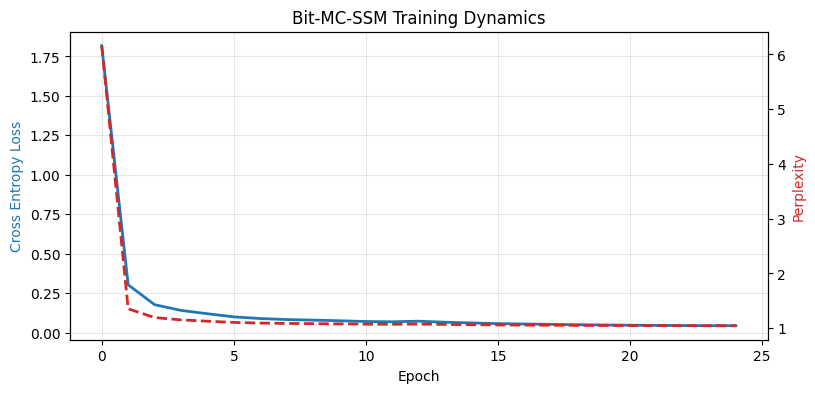

In [8]:
# ハイパーパラメータ設定
CONFIG = {
    "vocab_size": tokenizer.vocab_size,
    "d_model": 128,
    "n_layers": 4,
    "d_state": 16,
    "segment_len": 32,
    "top_k": 2,
    "lr": 2e-3,
    "epochs": 25,
}

model = BitMCSSMForCausalLM(
    vocab_size=CONFIG["vocab_size"],
    d_model=CONFIG["d_model"],
    n_layers=CONFIG["n_layers"],
    d_state=CONFIG["d_state"],
    segment_len=CONFIG["segment_len"],
    top_k=CONFIG["top_k"]
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"🧠 Model Parameters: {total_params / 1e6:.3f}M ({total_params:,} params)")

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"] * len(dataloader))

losses = []
ppls = []

print("\n🔥 Training Started...")
start_time = time.time()

for epoch in range(1, CONFIG["epochs"] + 1):
    model.train()
    total_loss = 0.0
    step_count = 0

    for x_b, y_b in dataloader:
        x_b, y_b = x_b.to(device), y_b.to(device)

        optimizer.zero_grad()
        _, loss = model(x_b, targets=y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        step_count += 1

    avg_loss = total_loss / step_count
    ppl = math.exp(min(avg_loss, 20.0))
    losses.append(avg_loss)
    ppls.append(ppl)

    if epoch % 5 == 0 or epoch == CONFIG["epochs"]:
        elapsed = time.time() - start_time
        print(f"Epoch [{epoch:2d}/{CONFIG['epochs']:2d}] | Loss: {avg_loss:.4f} | Perplexity: {ppl:.2f} | Elapsed: {elapsed:.1f}s")

# Loss & Perplexity グラフのプロット
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(losses, color="tab:blue", lw=2, label="Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross Entropy Loss", color="tab:blue")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(ppls, color="tab:red", lw=2, linestyle="--", label="Perplexity")
ax2.set_ylabel("Perplexity", color="tab:red")
plt.title("Bit-MC-SSM Training Dynamics")
plt.show()

## ✍️ 8. インタラクティブ・テキスト生成テスト

In [9]:
test_prompts = [
    "Once upon a time, Lily saw",
    "The frog hopped happily onto",
    "Max barked gently and guided",
]

print("=" * 70)
print("✨ Text Generation Results (Bit-MC-SSM):")
print("=" * 70)

for p in test_prompts:
    p_ids = torch.tensor([tokenizer.encode(p)], dtype=torch.long, device=device)
    gen_ids = model.generate(p_ids, max_new_tokens=120, temperature=0.7, top_k=20)
    gen_text = tokenizer.decode(gen_ids[0].tolist())
    print(f"\n[Prompt]: {p}")
    print(f"[Output]:\n{gen_text}")
    print("-" * 50)

✨ Text Generation Results (Bit-MC-SSM):

[Prompt]: Once upon a time, Lily saw
[Output]:
Once upon a time, Lily saw a tiny became the best of friends, and they slept peacefully all night morning, Lily saw a tiny green frog sitting near
--------------------------------------------------

[Prompt]: The frog hopped happily onto
[Output]:
The frog hopped happily onto a smooth stone and made a soft sound.
Lily found a shiny red apple under a tree. She wanted to share best of friends, a
--------------------------------------------------

[Prompt]: Max barked gently and guided
[Output]:
Max barked gently and guided the cool blue water.
Lily laughed and hugged the kitten safely back girl gave Max a tasty biscuit and watched the rippl
--------------------------------------------------


## 🔬 9. 1.58-bit 量子化重みの検証 (ヒストグラム確認)
モデル内の BitLinear 層の重みが正しく $\{-1, 0, +1\}$ の3値に集約されていることを可視化して検証します。

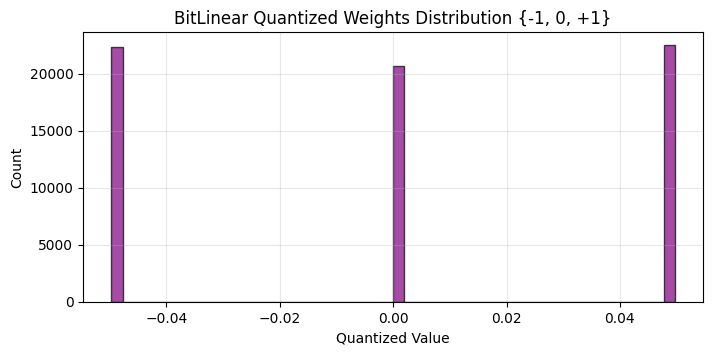

Unique ternary values in layer: [np.float32(-0.05), np.float32(0.0), np.float32(0.05)]


In [10]:
sample_weight = model.blocks[0].ffn_in.weight
q_weight = weight_quant(sample_weight).detach().cpu().numpy().flatten()

plt.figure(figsize=(8, 3.5))
plt.hist(q_weight, bins=50, color="purple", alpha=0.7, edgecolor="black")
plt.title("BitLinear Quantized Weights Distribution {-1, 0, +1}")
plt.xlabel("Quantized Value")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Unique ternary values in layer: {sorted(list(set(q_weight.round(decimals=3))))}")